In [2]:
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# 1. Load dataset
housing = fetch_california_housing()

# 2. Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# 3. Add target column
df['MedHouseVal'] = housing.target

# 4. Data Exploration (EDA)
print("Columns in dataset:", df.columns)
print("Rows, Columns =", df.shape)

# Show first 5 rows
print(df.head())

# Extract features only (dropping the target)
housing_features = df.drop('MedHouseVal', axis=1)
print(housing_features.head())

# 5. Data Cleaning
print("Missing Values:\n", df.isnull().sum())

# Note: This returns the dataframe with duplicates removed 
# (but doesn't modify df unless inplace=True is added)
df_cleaned = df.drop_duplicates()

# 6. Summary Statistics
display(df.describe())

Columns in dataset: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')
Rows, Columns = (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### *Target Distribution*

array([[<Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

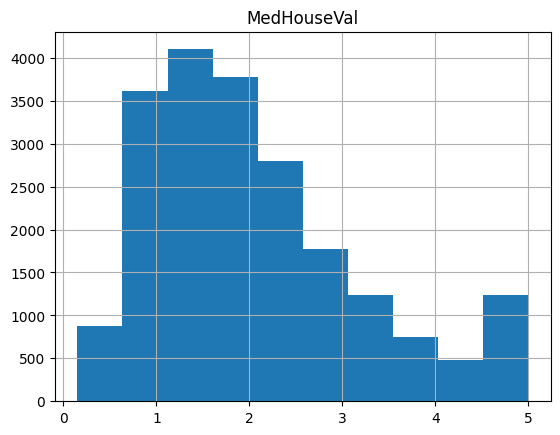

In [3]:
df.hist(column='MedHouseVal')

### *Train and split*

In [4]:
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

### *load Dataset*

In [5]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

In [6]:
X = df.drop("Price", axis=1)   # input features
y = df["Price"]               # target variable

### *Perform the train/test spilt

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,     # 20% test, 80% train
    random_state=42    # ensures reproducibility
)

In [8]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [9]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
15362,4.6050,16.0,7.002212,1.066372,1351.0,2.988938,33.36,-117.22
16623,2.7266,28.0,6.131915,1.256738,1650.0,2.340426,35.36,-120.83
18086,9.2298,25.0,7.237676,0.947183,1585.0,2.790493,37.31,-122.05
2144,2.7850,36.0,5.289030,0.983122,1227.0,2.588608,36.77,-119.76


In [10]:
y_train

14196    1.030
8267     3.821
17445    1.726
14265    0.934
2271     0.965
         ...  
11284    2.292
11964    0.978
5390     2.221
860      2.835
15795    3.250
Name: Price, Length: 16512, dtype: float64

In [11]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: Price, Length: 4128, dtype: float64

### *Linear regression*

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### *Train the model*

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred = model.predict(X_test)

In [64]:
y_test_pred = model.predict(X_test)

lr_test_r2 = r2_score(y_test, y_test_pred)
lr_test_mae = mean_absolute_error(y_test, y_test_pred)
lr_test_mse = mean_squared_error(y_test, y_test_pred)
lr_test_rmse = np.sqrt(lr_test_mse)

print("Test MAE:", lr_test_mae)
print("Test RMSE:", lr_test_rmse)
print("Test R²:", lr_test_r2)
print("Test MSE:", lr_test_mse)

Test MAE: 0.5332001304956546
Test RMSE: 0.7455813830127763
Test R²: 0.575787706032451
Test MSE: 0.5558915986952442


### *Saved with pickle*

In [16]:
import os
print(os.getcwd())

/Users/mac/Downloads


In [17]:
import pickle as pkl 
import joblib
filename = "linear_model.pkl"
joblib.dump(model, open(filename, "wb"))

In [18]:
load_model = joblib.load(open(filename, 'rb'))


    

In [19]:
predictions = load_model.predict(X_test)
print(predictions[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


### *Random Forest Regressor*

In [20]:
from sklearn.ensemble import RandomForestRegressor    

In [21]:
rf_model = RandomForestRegressor(
    n_estimators=100,     # number of trees
    random_state=42
)

In [22]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [48]:
y_pred = rf_model.predict(X_train)

In [50]:
y_rf_train_pred = rf_model.predict(X_train)

In [55]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Generate predictions
y_rf_train_pred = model.predict(X_train)

# Metrics
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_rf_train_pred))
rf_train_r2 = r2_score(y_train, y_rf_train_pred)
rf_train_mae = mean_absolute_error(y_train, y_rf_train_pred)
rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)

# Print results
print("Train RMSE:", rf_train_rmse)
print("Train R²:", rf_train_r2)
print("Train MAE:", rf_train_mae)
print("Train MSE:", rf_train_mse)

Train RMSE: 0.7196757085831574
Train R²: 0.6125511913966952
Train MAE: 0.5286283596581913
Train MSE: 0.5179331255246697


### *Gradient Boosting*

In [25]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)


In [26]:
y_gb_train_pred = gb.predict(X_train)
y_gb_test_pred = gb.predict(X_test)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# for MAE
gb_train_mae = mean_absolute_error(y_train, y_gb_train_pred)

# for MSE
gb_train_mse = mean_squared_error(y_train, y_gb_train_pred)

# for RMSE
gb_train_rmse = np.sqrt(gb_train_mse)

# forR^2
gb_train_r2 = r2_score(y_train, y_gb_train_pred)




print("MAE: ", gb_train_mae)
print("MSE: ", gb_train_mse)
print("RMSE: ", gb_train_rmse)
print("R²: ", gb_train_r2)

MAE:  0.3566326593955599
MSE:  0.2608082607140481
RMSE:  0.5106939011913576
R²:  0.8048978817773166


### **Lightgbm**

In [28]:
import lightgbm as lgb


In [29]:
from lightgbm import LGBMRegressor
lgb = LGBMRegressor()
lgb.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001613 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### ***Predicition of Lightgbm***

In [33]:
y_lgb_train_pred = lgb.predict(X_train)
y_lgb_test_pred = lgb.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# for MAE
lgb_train_mae = mean_absolute_error(y_train, y_lgb_train_pred)

# for MSE
lgb_train_mse = mean_squared_error(y_train, y_lgb_train_pred)

# for RMSE
lgb_train_rmse = np.sqrt(lgb_train_mse)

# forR^2
lgb_train_r2 = r2_score(y_train, y_lgb_train_pred)




print("MAE: ", lgb_train_mae)
print("MSE: ", lgb_train_mse)
print("RMSE: ", lgb_train_rmse)
print("R^2: ", lgb_train_r2)
MAE:  0.27229413696941673

MAE:  0.27229413696941673
MSE:  0.156226313206435
RMSE:  0.3952547446981946
R^2:  0.8831322115900523


In [66]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting", "LightGBM"],
    "MAE": [lr_train_mae, rf_train_mae, gb_train_mae, lgb_train_mae],
    "MSE": [lr_train_mse, rf_train_mse, gb_train_mse, lgb_train_mse],
    "RMSE": [lr_train_rmse, rf_train_rmse, gb_train_rmse, lgb_train_rmse],
    "R^2": [lr_train_r2, rf_train_r2, gb_train_r2, lgb_train_r2]

})

print(results)

               Model       MAE       MSE      RMSE       R^2
0  Linear Regression  0.533200  0.555892  0.745581  0.575788
1      Random Forest  0.528628  0.517933  0.719676  0.612551
2  Gradient Boosting  0.356633  0.260808  0.510694  0.804898
3           LightGBM  0.272294  0.156226  0.395255  0.883132


#### *Predicted and actual values*

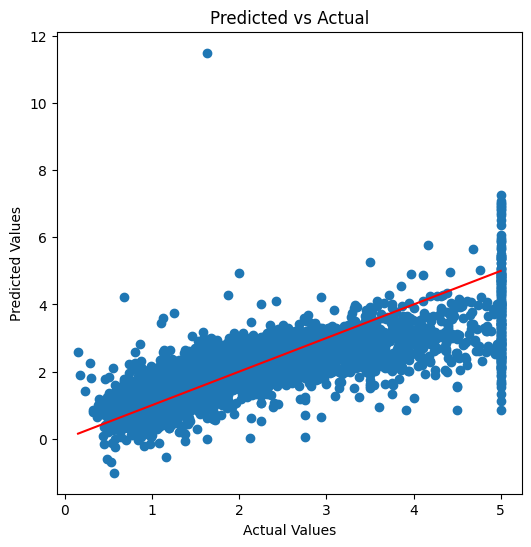

In [69]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")

plt.show()